# Real-time Bitcoin Price Analytics with Redis

This notebook provides a complete implementation example of a Redis-based system for Bitcoin price analytics. It demonstrates how to:

1. Connect to Redis and verify configuration
2. Fetch Bitcoin data from CoinGecko API
3. Store time series data in Redis
4. Retrieve and analyze Bitcoin price data
5. Visualize price trends and detect anomalies
6. Implement real-time price monitoring using Redis Pub/Sub

This notebook uses the Redis_utils.py module which provides wrapper functions for Redis operations.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
# Import necessary libraries
import os
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import logging
from dotenv import load_dotenv

# Import our Redis utilities
from Redis_utils import *

# Configure logging
logging.basicConfig(level=logging.INFO,
                   format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Load environment variables from .env file
load_dotenv()

# Get Redis connection parameters from environment variables
REDIS_HOST = os.getenv('REDIS_HOST', 'localhost')
REDIS_PORT = int(os.getenv('REDIS_PORT', 6379))
REDIS_PASSWORD = os.getenv('REDIS_PASSWORD', '')

# Display Redis configuration
print(f"Redis Configuration:")
print(f"Host: {REDIS_HOST}")
print(f"Port: {REDIS_PORT}")
print(f"Password: {'*****' if REDIS_PASSWORD else 'None'}")

Redis Configuration:
Host: localhost
Port: 6379
Password: None


## Verify Redis Connection

In [3]:
# Connect to Redis
try:
    redis_conn = connect_to_redis(REDIS_HOST, REDIS_PORT, REDIS_PASSWORD)
    print("Connected to Redis successfully!")
    
    # Verify Redis keys
    print("\nChecking for existing Bitcoin data in Redis:")
    keys = redis_conn.keys('bitcoin:*')
    if keys:
        print(f"Found {len(keys)} Bitcoin-related keys in Redis:")
        for key in keys[:5]:  # Show only first 5 keys to avoid clutter
            print(f"  - {key}")
        if len(keys) > 5:
            print(f"  - ... and {len(keys) - 5} more")
    else:
        print("No Bitcoin data found in Redis yet.")
except Exception as e:
    print(f"Error connecting to Redis: {e}")
    print("Please check your Redis connection settings in the .env file.")

2025-05-16 05:15:00,502 - Redis_utils - INFO - Successfully connected to Redis at localhost:6379


Connected to Redis successfully!

Checking for existing Bitcoin data in Redis:
Found 23 Bitcoin-related keys in Redis:
  - bitcoin:price:history:usd
  - bitcoin:pct_change:hourly
  - bitcoin:ma:72h
  - bitcoin:data:sources
  - bitcoin:ma:12h
  - ... and 18 more


## Create Database Tables (Redis Keys)

In [4]:
# Redis doesn't have traditional tables like SQL databases
# Instead, we use different key patterns for different types of data
print("Redis Key Structure for Bitcoin Data:")
print("------------------------------------")
print("bitcoin:current:price - Current Bitcoin price (string)")
print("bitcoin:latest - Complete data point with all fields (hash)")
print("bitcoin:price:history - Historical price time series (sorted set)")
print("bitcoin:last_updated - Timestamp of last update (string)")
print("\nChecking if these keys exist:")

# Check for current price key
if redis_conn.exists('bitcoin:current:price'):
    price = redis_conn.get('bitcoin:current:price')
    print(f"Current price exists: ${float(price):,.2f}")
else:
    print("Current price does not exist yet")

# Check for latest data hash
if redis_conn.exists('bitcoin:latest'):
    data = redis_conn.hgetall('bitcoin:latest')
    print(f"Latest data exists with {len(data)} fields")
else:
    print("Latest data hash does not exist yet")

# Check for price history
if redis_conn.exists('bitcoin:price:history'):
    count = redis_conn.zcard('bitcoin:price:history')
    print(f"Price history exists with {count} data points")
else:
    print("Price history does not exist yet")

Redis Key Structure for Bitcoin Data:
------------------------------------
bitcoin:current:price - Current Bitcoin price (string)
bitcoin:latest - Complete data point with all fields (hash)
bitcoin:price:history - Historical price time series (sorted set)
bitcoin:last_updated - Timestamp of last update (string)

Checking if these keys exist:
Current price does not exist yet
Latest data hash does not exist yet
Price history exists with 2 data points


## Fetch Bitcoin Data

In [5]:
# Fetch current Bitcoin price
try:
    current_data = fetch_bitcoin_price(currency='usd')
    print(f"Successfully fetched current Bitcoin price data:")
    print(f"Price: ${current_data['usd']:,.2f}")
    print(f"24h Change: {current_data['usd_24h_change']:.2f}%")
    print(f"Market Cap: ${current_data['usd_market_cap']:,.2f}")
    print(f"Last Updated: {datetime.fromtimestamp(current_data['last_updated_at'])}")
except Exception as e:
    print(f"Error fetching current Bitcoin price: {e}")

# Fetch historical data for the past 7 days
try:
    historical_data = fetch_bitcoin_historical(days=7)
    print(f"\nSuccessfully fetched historical Bitcoin data:")
    print(f"Price data points: {len(historical_data['prices'])}")
    print(f"Market cap data points: {len(historical_data['market_caps'])}")
    print(f"Volume data points: {len(historical_data['total_volumes'])}")
    
    # Display a sample of the historical data
    print("\nSample of historical data (5 most recent points):")
    for timestamp_ms, price in historical_data['prices'][-5:]:
        timestamp = datetime.fromtimestamp(timestamp_ms/1000)
        print(f"{timestamp}: ${price:,.2f}")
except Exception as e:
    print(f"Error fetching historical Bitcoin data: {e}")

2025-05-16 05:15:00,827 - Redis_utils - INFO - Successfully fetched Bitcoin price: 103939 USD
2025-05-16 05:15:00,969 - Redis_utils - INFO - Successfully fetched historical Bitcoin data for the last 7 days


Successfully fetched current Bitcoin price data:
Price: $103,939.00
24h Change: 1.17%
Market Cap: $2,064,573,319,457.31
Last Updated: 2025-05-16 05:14:36

Successfully fetched historical Bitcoin data:
Price data points: 168
Market cap data points: 168
Volume data points: 168

Sample of historical data (5 most recent points):
2025-05-16 01:09:59.990000: $103,812.14
2025-05-16 02:09:46.666000: $104,095.83
2025-05-16 03:04:37.759000: $104,209.19
2025-05-16 04:04:55.983000: $104,106.85
2025-05-16 05:14:15: $103,939.43


## Store Data in Redis

In [6]:
# Store current price data in Redis
try:
    success = store_bitcoin_price(redis_conn, current_data)
    if success:
        print("Successfully stored current Bitcoin price in Redis")
    else:
        print("Failed to store Bitcoin price in Redis")
except Exception as e:
    print(f"Error storing Bitcoin price: {e}")

# Process and store historical data in Redis
def process_historical_data(historical_data):
    """Process and store historical data in Redis."""
    print("Processing and storing historical data in Redis...")
    count = 0
    
    # Process price data
    for timestamp_ms, price in historical_data['prices']:
        # Convert timestamp from milliseconds to seconds
        timestamp = int(timestamp_ms/1000)
        
        # Find corresponding market cap and volume data
        market_cap = next((cap for ts, cap in historical_data['market_caps'] if ts == timestamp_ms), None)
        volume = next((vol for ts, vol in historical_data['total_volumes'] if ts == timestamp_ms), None)
        
        # Create data point
        data_point = {
            'usd': price,
            'usd_market_cap': market_cap,
            'usd_24h_vol': volume,
            'usd_24h_change': 0.0,  # Historical data doesn't include this
            'timestamp': timestamp,
            'last_updated_at': timestamp
        }
        
        # Store in Redis as a historical point
        store_historical_price(redis_conn, data_point)
        count += 1
    
    return count

try:
    count = process_historical_data(historical_data)
    print(f"Successfully stored {count} historical data points in Redis")
except Exception as e:
    print(f"Error storing historical data: {e}")

2025-05-16 05:15:01,045 - Redis_utils - INFO - Successfully stored Bitcoin price data in Redis


Successfully stored current Bitcoin price in Redis
Processing and storing historical data in Redis...
Successfully stored 168 historical data points in Redis


## Retrieve Data from Redis

In [7]:
# Retrieve Bitcoin price data for the last 7 days
try:
    # Calculate time range for the last 7 days
    end_time = int(time.time())
    start_time = end_time - (7 * 24 * 3600)  # 7 days ago
    
    # Get price history from Redis
    price_history = get_price_history(redis_conn, start_time, end_time)
    
    print(f"Retrieved {len(price_history)} price data points from Redis")
    
    # Convert to pandas DataFrame for analysis
    df = get_price_dataframe(price_history)
    
    # Display basic statistics
    print("\nBasic Statistics:")
    print(f"Mean price: ${df['price'].mean():,.2f}")
    print(f"Median price: ${df['price'].median():,.2f}")
    print(f"Min price: ${df['price'].min():,.2f}")
    print(f"Max price: ${df['price'].max():,.2f}")
    print(f"Price range: ${df['price'].max() - df['price'].min():,.2f}")
    print(f"Standard deviation: ${df['price'].std():,.2f}")
    
    # Calculate percent changes if we have enough data
    if len(df) >= 2:
        percent_change = calculate_percent_change(df)
        print(f"\nOverall change (first to last): {percent_change.iloc[-1]:.2f}%")
        
except Exception as e:
    print(f"Error retrieving Bitcoin price history: {e}")

2025-05-16 05:15:01,292 - Redis_utils - INFO - Retrieved 340 Bitcoin price records from history


Retrieved 340 price data points from Redis

Basic Statistics:
Mean price: $103,477.88
Median price: $103,626.08
Min price: $101,749.06
Max price: $104,778.26
Price range: $3,029.20
Standard deviation: $693.90

Overall change (first to last): -0.00%


## Visualization for 7-Day Price Time Series Plot

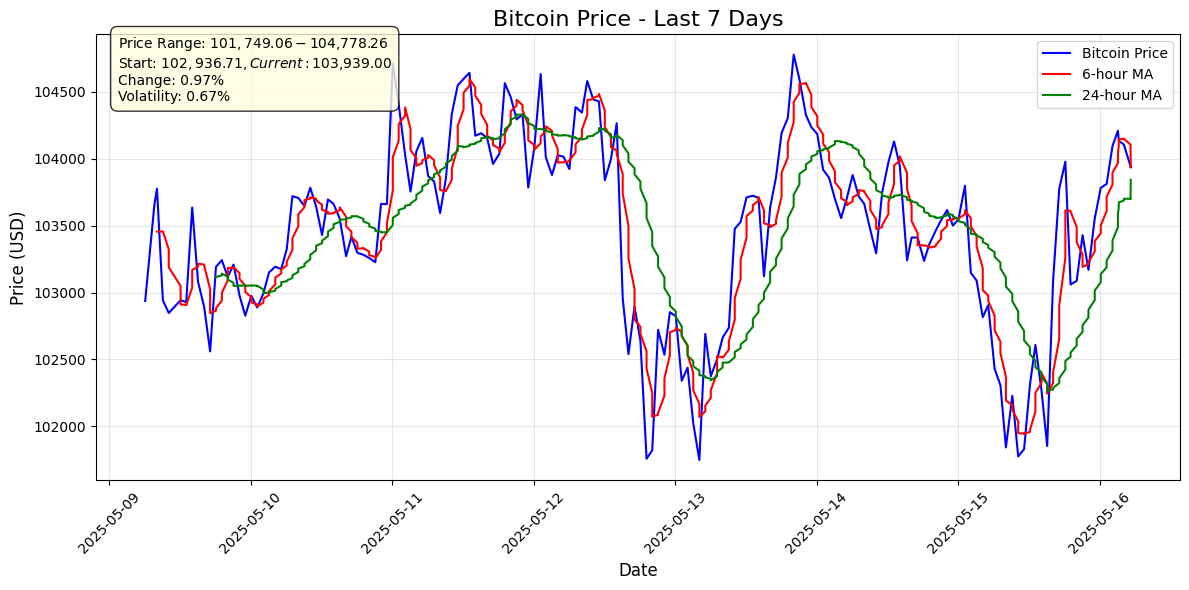

In [8]:
# Create a visualization of Bitcoin price data
try:
    # Check if we have enough data for visualization
    if len(df) < 10:
        print("Not enough data points for visualization. Fetching data from API...")
        # Fetch from API if not enough data in Redis
        historical_data = fetch_bitcoin_historical(days=7)
        timestamps = [ts/1000 for ts, _ in historical_data['prices']]
        prices = [price for _, price in historical_data['prices']]
        
        # Create a DataFrame
        df = pd.DataFrame({
            'timestamp': timestamps,
            'price': prices
        })
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
        df.set_index('datetime', inplace=True)
    
    # Calculate moving averages
    df['MA_6h'] = df['price'].rolling(window=6).mean()  # 6-hour moving average
    df['MA_24h'] = df['price'].rolling(window=24).mean()  # 24-hour moving average
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    
    # Plot price and moving averages
    plt.plot(df.index, df['price'], label='Bitcoin Price', color='blue')
    plt.plot(df.index, df['MA_6h'], label='6-hour MA', color='red')
    plt.plot(df.index, df['MA_24h'], label='24-hour MA', color='green')
    
    # Calculate and add key statistics to the plot
    min_price = df['price'].min()
    max_price = df['price'].max()
    start_price = df['price'].iloc[0]
    current_price = df['price'].iloc[-1]
    price_change = ((current_price - start_price) / start_price) * 100
    volatility = df['price'].std() / df['price'].mean() * 100
    
    stats_text = f"Price Range: ${min_price:,.2f} - ${max_price:,.2f}\n"
    stats_text += f"Start: ${start_price:,.2f}, Current: ${current_price:,.2f}\n"
    stats_text += f"Change: {price_change:.2f}%\n"
    stats_text += f"Volatility: {volatility:.2f}%"
    
    plt.annotate(stats_text, xy=(0.02, 0.85), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.5", fc="lightyellow", alpha=0.8))
    
    # Format the plot
    plt.title('Bitcoin Price - Last 7 Days', fontsize=16)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Format x-axis dates
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Show the plot
    plt.show()
    
except Exception as e:
    print(f"Error creating visualization: {e}")

## Real-time Updates with Redis Pub/Sub

In [9]:
# Demonstrate real-time updates using Redis Pub/Sub
# First, create a subscriber that listens for price updates

# Create a subscriber
print("Setting up a Redis Pub/Sub subscriber for Bitcoin price updates...")
pubsub = create_subscriber(redis_conn, channel='bitcoin_price_updates')

# Define a function to handle incoming messages
def handle_message(message):
    """Handle incoming message from Redis Pub/Sub."""
    if message['type'] == 'message':
        try:
            data = json.loads(message['data'])
            price = data.get('usd', 0)
            timestamp = data.get('last_updated_at', 0)
            dt = datetime.fromtimestamp(timestamp)
            print(f"[{dt}] Bitcoin price update: ${price:,.2f}")
        except:
            print(f"Received message: {message}")
    else:
        print(f"Received message: {message}")

# Simulate a few price updates
print("\nSimulating price updates (will publish 3 test updates)...")

# Publish a few test updates
for i in range(3):
    # Create a slightly modified price
    test_price = current_data['usd'] * (1 + (np.random.random() - 0.5) * 0.01)  # ±0.5% change
    
    # Create a test data point
    test_data = current_data.copy()
    test_data['usd'] = test_price
    test_data['last_updated_at'] = int(time.time())
    
    # Publish the update
    receivers = publish_price_update(redis_conn, test_data)
    print(f"Published price update: ${test_price:,.2f} to {receivers} subscribers")
    
    # Wait for a moment
    time.sleep(1)
    
    # Get one message from the channel
    message = pubsub.get_message()
    if message:
        handle_message(message)

# Clean up
pubsub.unsubscribe()
print("\nUnsubscribed from price updates channel")

2025-05-16 05:15:02,459 - Redis_utils - INFO - Subscribed to channel: bitcoin_price_updates
2025-05-16 05:15:02,468 - Redis_utils - INFO - Published price update to 1 subscribers


Setting up a Redis Pub/Sub subscriber for Bitcoin price updates...

Simulating price updates (will publish 3 test updates)...
Published price update: $104,235.25 to 1 subscribers


2025-05-16 05:15:03,473 - Redis_utils - INFO - Published price update to 1 subscribers


Received message: {'type': 'subscribe', 'pattern': None, 'channel': 'bitcoin_price_updates', 'data': 1}
Published price update: $104,051.57 to 1 subscribers


2025-05-16 05:15:04,477 - Redis_utils - INFO - Published price update to 1 subscribers


[2025-05-16 05:15:02] Bitcoin price update: $104,235.25
Published price update: $103,716.42 to 1 subscribers
[2025-05-16 05:15:03] Bitcoin price update: $104,051.57

Unsubscribed from price updates channel


## Real-time Price Alerting System with Redis Pub/Sub

This section demonstrates how to build a price alerting system using Redis Pub/Sub. The system monitors Bitcoin prices in real-time and triggers alerts when prices cross predefined thresholds or exhibit unusual behavior.

In [10]:
# Create alert system directly
alert_system = BitcoinPriceAlertSystem(redis_conn)

# Set up alerts
upper_threshold = current_price * 1.005  # 0.5% above current
lower_threshold = current_price * 0.995  # 0.5% below current

alert_system.add_threshold_alert(upper_threshold)
alert_system.add_threshold_alert(lower_threshold, is_upper=False)
alert_system.add_percent_change_alert(0.2, period_minutes=2)

# Run a short simulation manually
import numpy as np
duration = 20  # seconds
print(f"\nRunning price simulation for {duration} seconds...")
print("This will simulate price fluctuations to demonstrate the alert system")
print("(Watch for 🚨 ALERT messages in the output)")

# Start the alert system
alert_system.start_monitoring()

# Start time for our simulation
start_time = time.time()

try:
    while time.time() - start_time < duration:
        # Create price fluctuation with variance to trigger alerts
        random_change = (np.random.random() - 0.5) * 0.02  # ±1% change
        test_price = current_price * (1 + random_change)
        
        # Create a test data point
        test_data = {
            'usd': test_price,
            'usd_24h_change': random_change * 100,
            'usd_market_cap': 1.9e12,  # Approximate market cap
            'last_updated_at': int(time.time())
        }
        
        # Publish the update
        publish_price_update(redis_conn, test_data)
        
        # Display the update
        dt = datetime.now().strftime("%H:%M:%S")
        print(f"[{dt}] Published price update: ${test_price:,.2f} (change: {random_change*100:+.2f}%)")
        
        # Sleep for a random time between updates
        time.sleep(np.random.uniform(1.0, 2.0))
        
except KeyboardInterrupt:
    print("\nSimulation interrupted by user")
finally:
    # Stop the alert system
    alert_system.stop_monitoring()
    print("Alert system simulation completed")

# Get alerts
alerts = alert_system.alerts

2025-05-16 05:15:05,579 - Redis_utils - INFO - Added upper threshold alert at $104,458.69
2025-05-16 05:15:05,581 - Redis_utils - INFO - Added lower threshold alert at $103,419.30
2025-05-16 05:15:05,585 - Redis_utils - INFO - Added 0.2% change alert over 2 minute period
2025-05-16 05:15:05,590 - Redis_utils - INFO - Subscribed to channel: bitcoin_price_updates
2025-05-16 05:15:05,592 - Redis_utils - INFO - Alert monitoring loop started...
2025-05-16 05:15:05,594 - Redis_utils - INFO - Bitcoin price alert system started
2025-05-16 05:15:05,602 - Redis_utils - INFO - Published price update to 1 subscribers



Running price simulation for 20 seconds...
This will simulate price fluctuations to demonstrate the alert system
(Watch for 🚨 ALERT messages in the output)
[05:15:05] Published price update: $104,916.29 (change: +0.94%)


2025-05-16 05:15:05,701 - Redis_utils - INFO - ALERT at 2025-05-16 05:15:05: Upper threshold of $104,458.69 exceeded
2025-05-16 05:15:06,800 - Redis_utils - INFO - Published price update to 1 subscribers
2025-05-16 05:15:06,811 - Redis_utils - INFO - ALERT at 2025-05-16 05:15:06: Price changed by 0.2% within 2 minutes (moved down 0.8%)


[05:15:06] Published price update: $104,125.50 (change: +0.18%)


2025-05-16 05:15:08,421 - Redis_utils - INFO - Published price update to 1 subscribers


...

[05:15:23] Published price update: $103,749.16 (change: -0.18%)


2025-05-16 05:15:25,369 - Redis_utils - INFO - Published price update to 1 subscribers


[05:15:25] Published price update: $103,576.70 (change: -0.35%)


2025-05-16 05:15:26,423 - Redis_utils - INFO - Bitcoin price alert system stopped


Alert system simulation completed


## Calculating Moving Averages with Redis

This section demonstrates how to calculate moving averages using Redis. While Redis doesn't have native time series analytics functions, we can implement a pattern where we calculate moving averages as we store data and keep these pre-computed values in Redis for fast retrieval.

## Advanced Analysis and Anomaly Detection

2025-05-16 05:15:26,517 - Redis_utils - INFO - Retrieved 340 Bitcoin price records from history


Calculating moving averages using Redis...
Stored 6h moving average in Redis key: bitcoin:ma:6h
Stored 12h moving average in Redis key: bitcoin:ma:12h
Stored 24h moving average in Redis key: bitcoin:ma:24h


2025-05-16 05:15:26,727 - Redis_utils - INFO - Retrieved 340 Bitcoin price records from history


Stored 72h moving average in Redis key: bitcoin:ma:72h
No data found for 6h moving average
No data found for 12h moving average
No data found for 24h moving average
No data found for 72h moving average


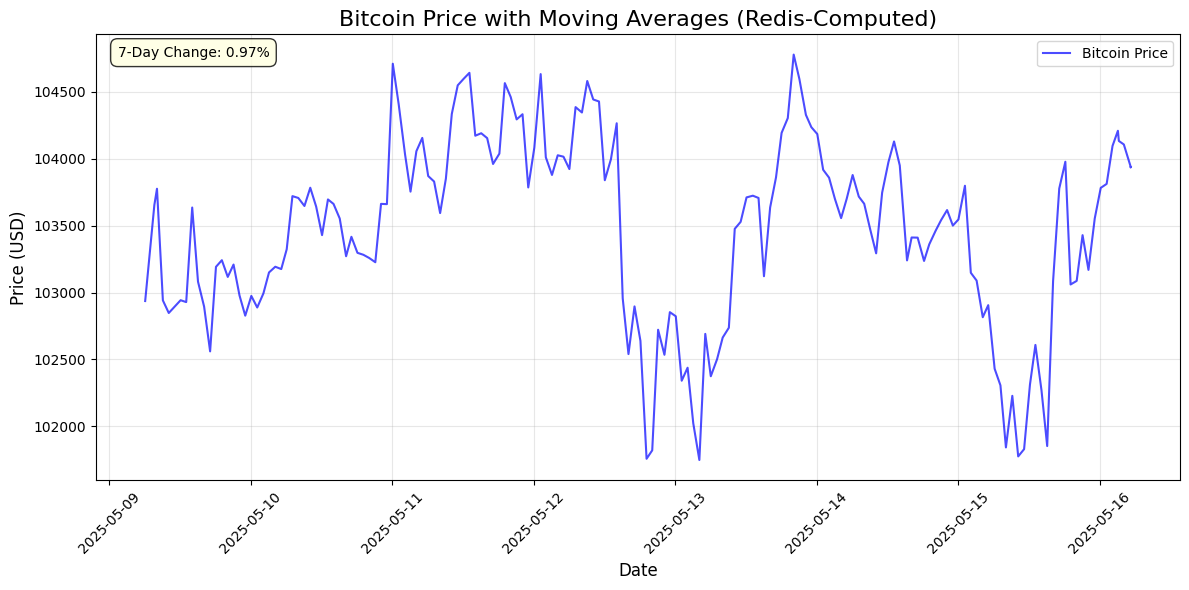

In [11]:
# Calculating moving averages using Redis
print("Calculating moving averages using Redis...")

# Define function to calculate and store moving averages
def calculate_store_moving_averages(redis_conn, window_sizes=[6, 24]):
    """
    Calculate moving averages from Redis data and store results back in Redis.
    
    Parameters:
        redis_conn: Redis connection
        window_sizes: List of window sizes for moving averages (in hours)
    
    Returns:
        DataFrame with price data and moving averages
    """
    # First, get the raw price data from Redis
    end_time = int(time.time())
    start_time = end_time - (7 * 24 * 3600)  # 7 days ago
    price_history = get_price_history(redis_conn, start_time, end_time)
    
    if len(price_history) < max(window_sizes):
        print(f"Not enough data points for {max(window_sizes)}h moving average. Need at least {max(window_sizes)} points.")
        return None
    
    # Convert to DataFrame
    df = get_price_dataframe(price_history)
    df = df.sort_index()  # Ensure chronological order
    
    # Calculate moving averages
    for window in window_sizes:
        # Calculate moving average
        ma_key = f"bitcoin:ma:{window}h"
        df[f'MA_{window}h'] = df['price'].rolling(window=window).mean()
        
        # Store each moving average value in Redis
        pipeline = redis_conn.pipeline()
        for timestamp, row in df.iterrows():
            if pd.notna(row[f'MA_{window}h']):
                # Store in sorted set with timestamp as score
                unix_time = int(timestamp.timestamp())
                pipeline.zadd(ma_key, {str(unix_time): float(row[f'MA_{window}h'])})
        
        # Execute all commands in the pipeline
        pipeline.execute()
        print(f"Stored {window}h moving average in Redis key: {ma_key}")
    
    return df

# Retrieve and plot moving averages from Redis
def plot_moving_averages_from_redis(redis_conn, window_sizes=[6, 24]):
    """
    Retrieve pre-computed moving averages from Redis and plot them.
    
    Parameters:
        redis_conn: Redis connection
        window_sizes: List of window sizes for moving averages (in hours)
    """
    # Get raw price data
    end_time = int(time.time())
    start_time = end_time - (7 * 24 * 3600)  # 7 days ago
    price_history = get_price_history(redis_conn, start_time, end_time)
    
    if not price_history:
        print("No price data available in Redis.")
        return
    
    # Convert to DataFrame
    df = get_price_dataframe(price_history)
    
    # Create figure for plotting
    plt.figure(figsize=(12, 6))
    
    # Plot raw price data
    plt.plot(df.index, df['price'], label='Bitcoin Price', color='blue', alpha=0.7)
    
    # Retrieve and plot moving averages
    colors = ['red', 'green', 'purple', 'orange']
    for i, window in enumerate(window_sizes):
        ma_key = f"bitcoin:ma:{window}h"
        
        # Check if moving average exists in Redis
        if redis_conn.exists(ma_key):
            # Get moving average data from Redis
            ma_data = redis_conn.zrangebyscore(ma_key, start_time, end_time, withscores=True)
            
            if ma_data:
                # Convert to DataFrame
                ma_df = pd.DataFrame([
                    (datetime.fromtimestamp(int(score)), float(value)) 
                    for value, score in ma_data
                ], columns=['timestamp', 'ma_value'])
                ma_df.set_index('timestamp', inplace=True)
                
                # Plot moving average
                plt.plot(ma_df.index, ma_df['ma_value'], 
                         label=f'{window}h Moving Average', 
                         color=colors[i % len(colors)])
                
                print(f"Retrieved {len(ma_df)} data points for {window}h moving average")
            else:
                print(f"No data found for {window}h moving average")
        else:
            print(f"Moving average key {ma_key} does not exist in Redis")
    
    # Calculate percent change
    if len(df) >= 2:
        first_price = df['price'].iloc[0]
        last_price = df['price'].iloc[-1]
        percent_change = ((last_price - first_price) / first_price) * 100
        
        # Add percent change to the plot
        plt.annotate(f"7-Day Change: {percent_change:.2f}%", 
                     xy=(0.02, 0.95), xycoords='axes fraction',
                     bbox=dict(boxstyle="round,pad=0.5", fc="lightyellow", alpha=0.8))
    
    # Format the plot
    plt.title('Bitcoin Price with Moving Averages (Redis-Computed)', fontsize=16)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.xlabel('Date', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Format x-axis dates
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# Calculate and store moving averages in Redis
df_with_ma = calculate_store_moving_averages(redis_conn, window_sizes=[6, 12, 24, 72])

# Plot moving averages from Redis
if df_with_ma is not None:
    plot_moving_averages_from_redis(redis_conn, window_sizes=[6, 12, 24, 72])
else:
    print("Could not calculate moving averages due to insufficient data")

## Redis Time Series Extensions for Advanced Analytics

Redis can be extended with modules like RedisTimeSeries for more advanced time series operations. Below, we simulate some of the functions you would get with RedisTimeSeries by implementing them using standard Redis commands and Python analytics.

2025-05-16 05:15:27,460 - Redis_utils - INFO - Retrieved 340 Bitcoin price records from history


Implementing percent change and volatility tracking...
Stored percent changes and volatility data in Redis


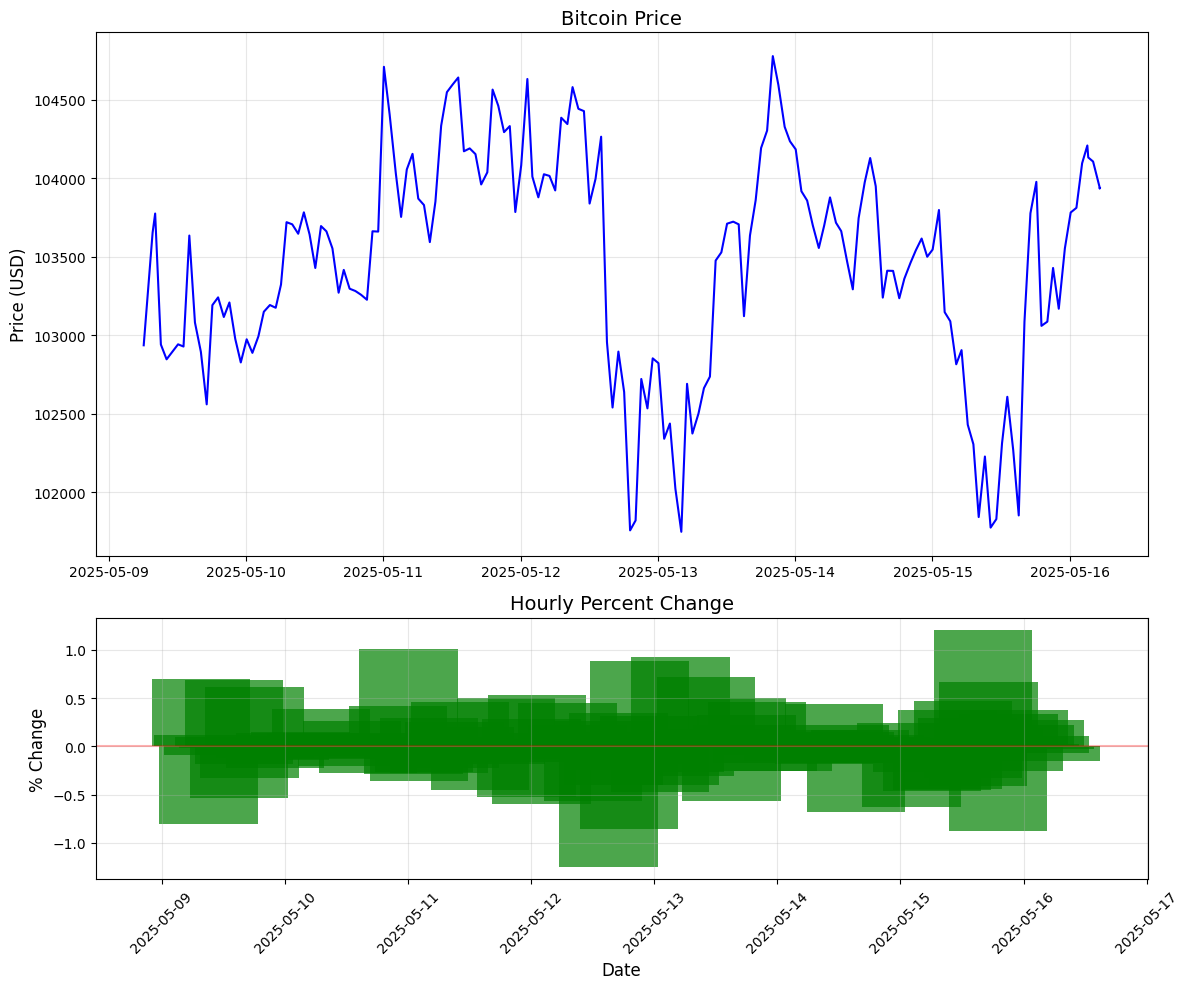


Recent Price Changes (from Redis):
----------------------------------
Hourly changes (last 24 hours):
  1 hour(s) ago: 0.00%
  2 hour(s) ago: -0.25%
  3 hour(s) ago: 0.00%
  4 hour(s) ago: 0.37%
  5 hour(s) ago: 0.00%
  6 hour(s) ago: 0.22%
  7 hour(s) ago: 0.00%
  8 hour(s) ago: 0.03%
  9 hour(s) ago: 0.00%
  10 hour(s) ago: 0.27%
  11 hour(s) ago: 0.00%
  12 hour(s) ago: 0.11%
  13 hour(s) ago: 0.00%
  14 hour(s) ago: -0.07%
  15 hour(s) ago: -0.00%
  16 hour(s) ago: -0.03%
  17 hour(s) ago: 0.00%
  18 hour(s) ago: -0.16%
  19 hour(s) ago: -0.00%
  20 hour(s) ago: -0.01%
  21 hour(s) ago: 0.01%
  22 hour(s) ago: -0.00%
  23 hour(s) ago: -0.00%

Daily changes (last 7 days):
  1 day(s) ago: 0.83%
  2 day(s) ago: 1.22%
  3 day(s) ago: -1.57%
  4 day(s) ago: -0.19%
  5 day(s) ago: -1.06%
  6 day(s) ago: 2.06%
  7 day(s) ago: 0.83%


In [12]:
# Simulate Redis TimeSeries functions for percent change and volatility tracking
print("Implementing percent change and volatility tracking...")

# Function to calculate and store percent changes in Redis
def calculate_store_percent_changes(redis_conn):
    """
    Calculate percent changes from Redis data and store results back in Redis.
    """
    # Get the raw price data from Redis
    end_time = int(time.time())
    start_time = end_time - (7 * 24 * 3600)  # 7 days ago
    price_history = get_price_history(redis_conn, start_time, end_time)
    
    if len(price_history) < 2:
        print("Not enough data points for percent change calculation.")
        return None
    
    # Convert to DataFrame
    df = get_price_dataframe(price_history)
    df = df.sort_index()  # Ensure chronological order
    
    # Calculate percent changes
    df['pct_change'] = df['price'].pct_change() * 100
    
    # Calculate hourly, daily, and weekly percent changes
    hourly_changes = {}
    daily_changes = {}
    
    # Store each percent change value in Redis
    pipeline = redis_conn.pipeline()
    
    # Store all percent changes
    pct_change_key = "bitcoin:pct_change:all"
    for timestamp, row in df.iterrows():
        if pd.notna(row['pct_change']):
            # Store in sorted set with timestamp as score
            unix_time = int(timestamp.timestamp())
            pipeline.zadd(pct_change_key, {str(unix_time): float(row['pct_change'])})
    
    # Calculate and store hourly changes (last 24 hours)
    last_24h = df.tail(24)
    for i in range(1, len(last_24h)):
        hour = i
        hourly_change = ((last_24h['price'].iloc[i] / last_24h['price'].iloc[i-1]) - 1) * 100
        hourly_changes[hour] = hourly_change
        pipeline.hset("bitcoin:pct_change:hourly", str(hour), str(hourly_change))
    
    # Calculate and store daily changes (last 7 days)
    if len(df) >= 24*7:
        for i in range(7):
            day = i + 1
            day_ago = len(df) - (24 * i) - 1
            week_ago = len(df) - (24 * (i+1)) - 1
            if week_ago >= 0:
                daily_change = ((df['price'].iloc[day_ago] / df['price'].iloc[week_ago]) - 1) * 100
                daily_changes[day] = daily_change
                pipeline.hset("bitcoin:pct_change:daily", str(day), str(daily_change))
    
    # Calculate and store volatility
    df['rolling_std'] = df['price'].rolling(window=24).std()
    df['volatility'] = (df['rolling_std'] / df['price']) * 100
    
    volatility_key = "bitcoin:volatility:24h"
    for timestamp, row in df.iterrows():
        if pd.notna(row['volatility']):
            unix_time = int(timestamp.timestamp())
            pipeline.zadd(volatility_key, {str(unix_time): float(row['volatility'])})
    
    # Execute all commands in the pipeline
    pipeline.execute()
    print(f"Stored percent changes and volatility data in Redis")
    
    return df, hourly_changes, daily_changes

# Calculate and store percent changes in Redis
result = calculate_store_percent_changes(redis_conn)

if result:
    df, hourly_changes, daily_changes = result
    
    # Create visualization of percent changes and volatility
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
    
    # Plot price in top subplot
    ax1.plot(df.index, df['price'], label='Bitcoin Price', color='blue')
    ax1.set_title('Bitcoin Price', fontsize=14)
    ax1.set_ylabel('Price (USD)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Plot percent change in bottom subplot
    ax2.bar(df.index, df['pct_change'], label='Hourly % Change', color='green', alpha=0.7)
    ax2.axhline(y=0, color='r', linestyle='-', alpha=0.3)
    ax2.set_title('Hourly Percent Change', fontsize=14)
    ax2.set_ylabel('% Change', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Format x-axis dates
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Display the plot
    plt.show()
    
    # Show summary of recent percent changes
    print("\nRecent Price Changes (from Redis):")
    print("----------------------------------")
    print("Hourly changes (last 24 hours):")
    for hour, change in sorted(hourly_changes.items()):
        print(f"  {hour} hour(s) ago: {change:.2f}%")
    
    print("\nDaily changes (last 7 days):")
    for day, change in sorted(daily_changes.items()):
        print(f"  {day} day(s) ago: {change:.2f}%")
else:
    print("Could not calculate percent changes due to insufficient data")

Performing advanced price analysis and anomaly detection...
Detected 3 price anomalies in the last 7 days


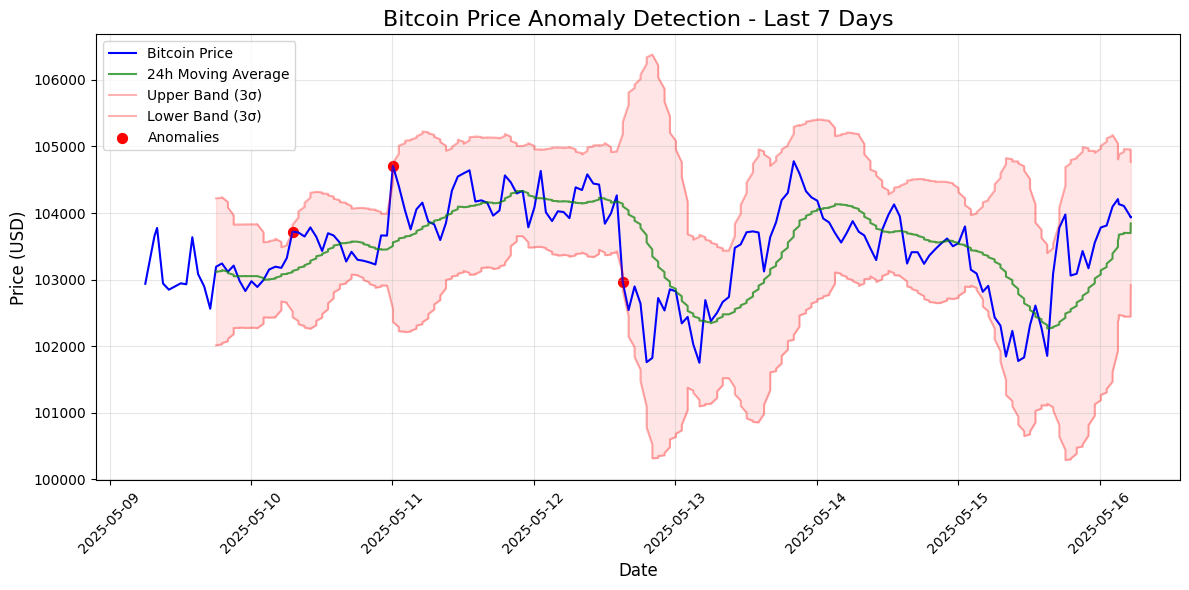

In [13]:
# Perform more advanced analytics on Bitcoin price data
try:
    # Make sure we have enough data
    if len(df) >= 24:  # At least 24 data points (hours)
        print("Performing advanced price analysis and anomaly detection...")
        
        # Calculate additional metrics
        df['volatility'] = df['price'].rolling(window=12).std() / df['price'].rolling(window=12).mean() * 100
        df['pct_change'] = df['price'].pct_change() * 100
        
        # Detect price anomalies
        # An anomaly is when price moves more than 3 standard deviations from the 24h mean
        window = 24
        df['rolling_mean'] = df['price'].rolling(window=window).mean()
        df['rolling_std'] = df['price'].rolling(window=window).std()
        df['upper_band'] = df['rolling_mean'] + (df['rolling_std'] * 3)
        df['lower_band'] = df['rolling_mean'] - (df['rolling_std'] * 3)
        
        # Mark anomalies
        df['anomaly'] = ((df['price'] > df['upper_band']) | (df['price'] < df['lower_band']))
        anomalies = df[df['anomaly'] == True]
        
        # Plot with anomalies
        plt.figure(figsize=(12, 6))
        
        # Plot price
        plt.plot(df.index, df['price'], label='Bitcoin Price', color='blue')
        
        # Plot bands
        plt.plot(df.index, df['rolling_mean'], label='24h Moving Average', color='green', alpha=0.7)
        plt.plot(df.index, df['upper_band'], label='Upper Band (3σ)', color='red', alpha=0.3)
        plt.plot(df.index, df['lower_band'], label='Lower Band (3σ)', color='red', alpha=0.3)
        plt.fill_between(df.index, df['lower_band'], df['upper_band'], color='red', alpha=0.1)
        
        # Plot anomalies
        if not anomalies.empty:
            plt.scatter(anomalies.index, anomalies['price'], color='red', s=50, label='Anomalies')
            print(f"Detected {len(anomalies)} price anomalies in the last 7 days")
        else:
            print("No price anomalies detected in the last 7 days")
        
        # Format the plot
        plt.title('Bitcoin Price Anomaly Detection - Last 7 Days', fontsize=16)
        plt.ylabel('Price (USD)', fontsize=12)
        plt.xlabel('Date', fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Format x-axis dates
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        # Show the plot
        plt.show()
    else:
        print("Not enough data for advanced analytics")
        
except Exception as e:
    print(f"Error performing advanced analytics: {e}")